### step 1: import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [23]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

### step 2: load the dataset

In [4]:
data = pd.read_csv('./data/spam_ham_dataset.csv')

In [5]:
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [6]:
data.shape

(5171, 4)

<Axes: xlabel='label', ylabel='count'>

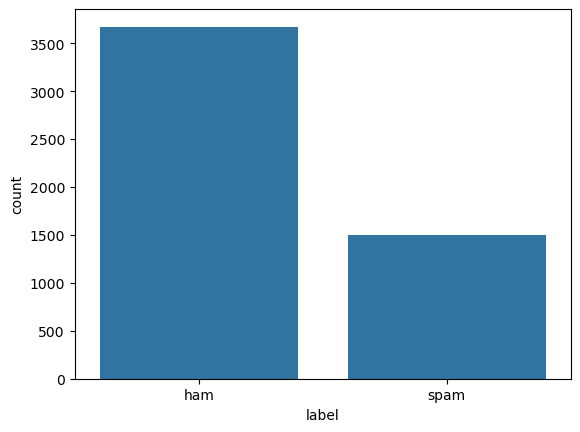

In [7]:
sns.countplot(x = 'label', data = data)  # 根据label特征计数

### step 3: balance the dataset

In [8]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

In [9]:
# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(len(spam_msg), random_state=42)

In [10]:
# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

In [11]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,Subject: conoco - big cowboy\r\ndarren :\r\ni ...,0
1,2982,ham,Subject: feb 01 prod : sale to teco gas proces...,0
2,2711,ham,Subject: california energy crisis\r\ncaliforni...,0
3,3116,ham,Subject: re : nom / actual volume for april 23...,0
4,1314,ham,Subject: eastrans nomination changes effective...,0


([<matplotlib.axis.XTick at 0x1846ec31780>,
 [Text(0, 0, 'Ham (Not Spam)'), Text(1, 0, 'Spam')])

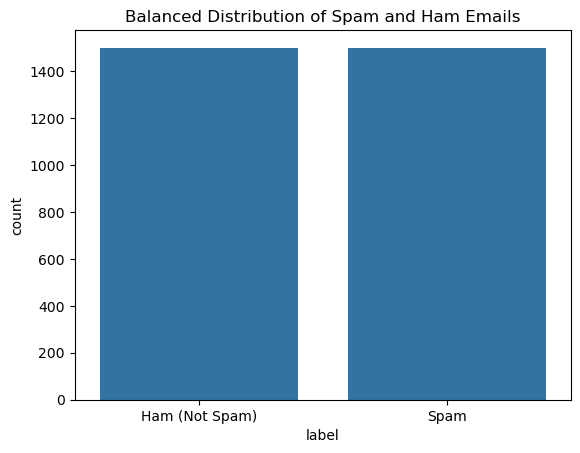

In [12]:
# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])

### step 4: clean the text

In [13]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')

In [14]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


#### punctuations removal

str.maketrans(from_str, to_str, deletechars)

创建一个字符映射转换表。这个转换表本质上是一个字典，它定义了字符之间的替换规则，后续可以被 str.translate() 方法使用，以实现字符串中字符的批量替换。

from_str：必须是一个字符串，包含要被替换的字符。

to_str：必须是一个与 from_str 长度相同的字符串，包含替换后的字符，且 from_str 中的每个字符会依次对应 to_str 中相同位置的字符。

deletechars：一个字符串，包含要从from_str中删除的字符。

In [15]:
def remove_punctuations(text):
    temp = str.maketrans('', '', string.punctuation)
    return text.translate(temp)

In [19]:
balanced_data['text'] = balanced_data['text'].apply(remove_punctuations)

In [20]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


#### stopwords removal

In [21]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')
    imp_words = list()
    
    for word in str(text).split():
        word = word.lower()
        
        if word not in stop_words:
            imp_words.append(word)
    
    output = ' '.join(imp_words)
    return output

In [26]:
balanced_data['text'] = balanced_data['text'].apply(remove_stopwords)

In [27]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


### step 5: visualization word cloud

In [28]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')

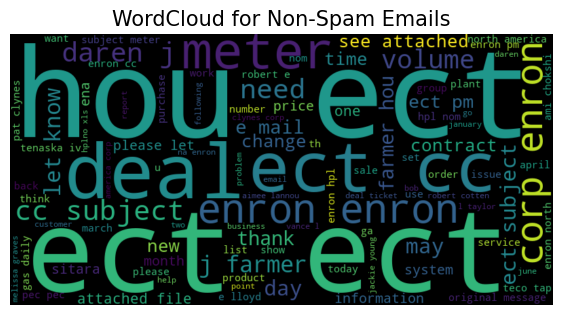

In [29]:
plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')

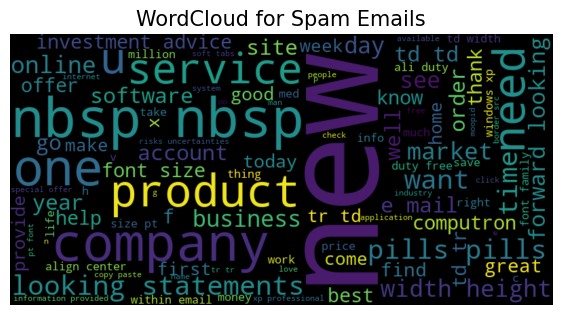

In [30]:
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

### step 6: tokenization and padding

In [31]:
train_X, test_X, train_Y, test_Y = train_test_split(balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42)

In [32]:
tokenizer = Tokenizer()

In [33]:
tokenizer.fit_on_texts(train_X)

In [34]:
train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

In [37]:
max_len = 100  # 设置token长度

`keras.preprocessing.sequence.pad_sequences(sequences, maxlen=None, dtype='int32', padding='pre', truncating='pre', value=0.)`

将序列转化为经过填充以后的一个长度相同的新序列新序列。

`sequences`：浮点数或整数构成的两层嵌套列表

`maxlen`：None或整数，为序列的最大长度。大于此长度的序列将被截短，小于此长度的序列将在后部填0.

`dtype`：返回的numpy array的数据类型

`padding`：`pre`或`post`，确定当需要补0时，在序列的起始还是结尾补

`truncating`：`pre`或`post`，确定当需要截断序列时，从起始还是结尾截断

`value`：浮点数，此值将在填充时代替默认的填充值0

In [38]:
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

In [42]:
# 将标签转化为整型
train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

### step 7: Define the Model

In [67]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

In [68]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

In [48]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 32)           1274912   
                                                                 
 lstm (LSTM)                 (None, 16)                3136      
                                                                 
 dense (Dense)               (None, 32)                544       
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,278,625
Trainable params: 1,278,625
Non-trainable params: 0
_________________________________________________________________


### step 8: Train the Model

In [72]:
es = EarlyStopping(patience=5, monitor='val_accuracy', restore_best_weights=True)

In [50]:
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

In [73]:
history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 [==============================] - 2s 29ms/step - loss: 0.2497 - accuracy: 0.9270 - val_loss: 0.2191 - val_accuracy: 0.9433 - lr: 0.0010
Epoch 2/20
75/75 [==============================] - 2s 28ms/step - loss: 0.1635 - accuracy: 0.9608 - val_loss: 0.2320 - val_accuracy: 0.9350 - lr: 0.0010
Epoch 3/20
75/75 [==============================] - 2s 28ms/step - loss: 0.1286 - accuracy: 0.9704 - val_loss: 0.2229 - val_accuracy: 0.9450 - lr: 0.0010
Epoch 4/20
75/75 [==============================] - 2s 28ms/step - loss: 0.0897 - accuracy: 0.9817 - val_loss: 0.2060 - val_accuracy: 0.9517 - lr: 5.0000e-04
Epoch 5/20
75/75 [==============================] - 2s 28ms/step - loss: 0.0707 - accuracy: 0.9862 - val_loss: 0.1994 - val_accuracy: 0.9550 - lr: 5.0000e-04
Epoch 6/20
75/75 [==============================] - 2s 28ms/step - loss: 0.0641 - accuracy: 0.9875 - val_loss: 0.2053 - val_accuracy: 0.9550 - lr: 5.0000e-04
Epoch 7/20
75/75 [==============================] - 2s 28ms/step

In [74]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)

19/19 [==============================] - 0s 6ms/step - loss: 0.1428 - accuracy: 0.9700


In [75]:
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

Test Loss : 0.1427937150001526
Test Accuracy : 0.9700000286102295


In [55]:
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

Test Loss : 0.07749617099761963
Test Accuracy : 0.9850000143051147


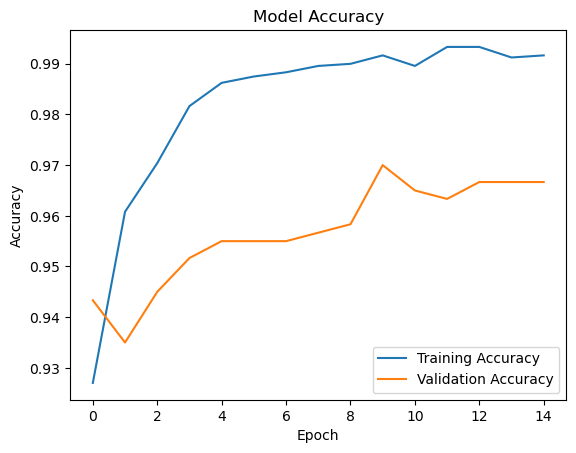

In [76]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()